# Backpropagation through time (BPTT)

**Learning objective:** Use TensorFlow GradientTape to see how a final loss sends gradients through the unrolled recurrent computation.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:13:29.437142: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974809.452367    2980 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974809.456699    2980 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:13:31.126977: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Training unfolds recurrence conceptually into a deep graph whose depth is the number of timesteps. The same recurrent matrix participates repeatedly, so its gradient accumulates contributions from many temporal paths.


In [2]:
rnn=tf.keras.layers.SimpleRNN(3); dense=tf.keras.layers.Dense(1)
x=tf.random.normal((8,12,2),seed=SEED); y=tf.random.normal((8,1),seed=SEED+1)
with tf.GradientTape() as tape:
    h=rnn(x); pred=dense(h); loss=tf.reduce_mean(tf.square(pred-y))
vars_=rnn.trainable_variables+dense.trainable_variables
grads=tape.gradient(loss,vars_)
table=pd.DataFrame({"variable":[v.name for v in vars_],"shape":[str(tuple(v.shape)) for v in vars_],"gradient_norm":[float(tf.norm(g)) for g in grads]})
print("loss:",float(loss)); display(table)


loss: 2.6994190216064453


,variable,shape,gradient_norm
0,kernel,"(2, 3)",1.777470
1,recurrent_kernel,"(3, 3)",0.942483
2,bias,"(3,)",0.347061
3,kernel,"(3, 1)",1.578379
4,bias,"(1,)",1.021727


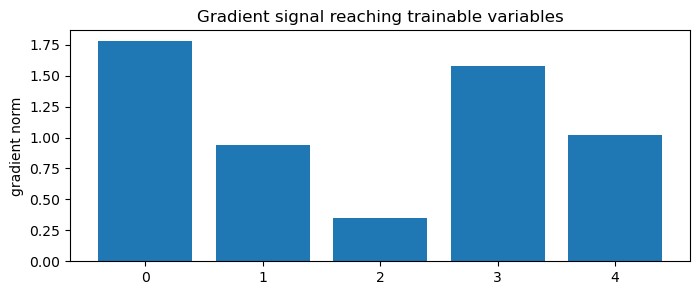

In [3]:
plt.figure(figsize=(8,3)); plt.bar(np.arange(len(grads)), [float(tf.norm(g)) for g in grads]); plt.xticks(np.arange(len(grads)), range(len(grads))); plt.ylabel("gradient norm"); plt.title("Gradient signal reaching trainable variables"); plt.show()


BPTT is ordinary reverse-mode automatic differentiation applied to the unrolled recurrent graph. TensorFlow builds and differentiates that graph for us.
